In [1]:
#  STEP 1 — Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
#  STEP 2 — Load the CSV file

df = pd.read_csv("D:\HR_Analysis_Dashboard\data\WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Shape (rows, columns):", df.shape)


print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())


Shape (rows, columns): (1470, 35)

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatis

In [4]:
#  STEP 3 — Drop useless columns

cols_to_drop = ["EmployeeCount", "StandardHours", "Over18"]
df = df.drop(columns=cols_to_drop)

print("\nNew shape after dropping useless columns:", df.shape)




New shape after dropping useless columns: (1470, 32)


In [5]:
#  STEP 4 — Understand your target variable

print("\nAttrition value counts:")
print(df["Attrition"].value_counts())

print("\nAttrition percentage:")
print(df["Attrition"].value_counts(normalize=True) * 100)

df["Attrition_Num"] = df["Attrition"].map({"Yes": 1, "No": 0})



Attrition value counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition percentage:
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


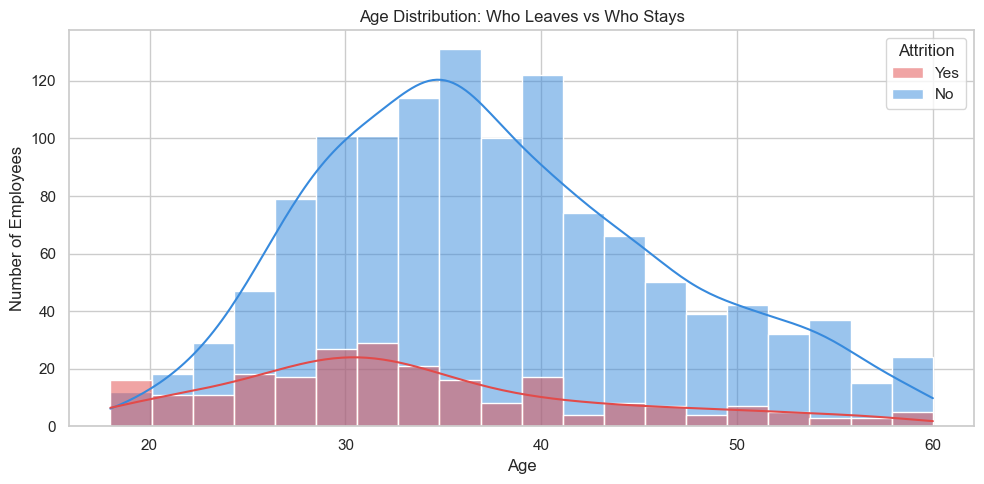

In [6]:
#  STEP 5 — Plot: Age distribution

plt.figure(figsize=(10, 5))


sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",      
    bins=20,
    kde=True,           
    palette={"Yes": "#E24B4A", "No": "#378ADD"}
)

plt.title("Age Distribution: Who Leaves vs Who Stays")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.savefig("plot1_age_distribution.png", dpi=150)
plt.show()


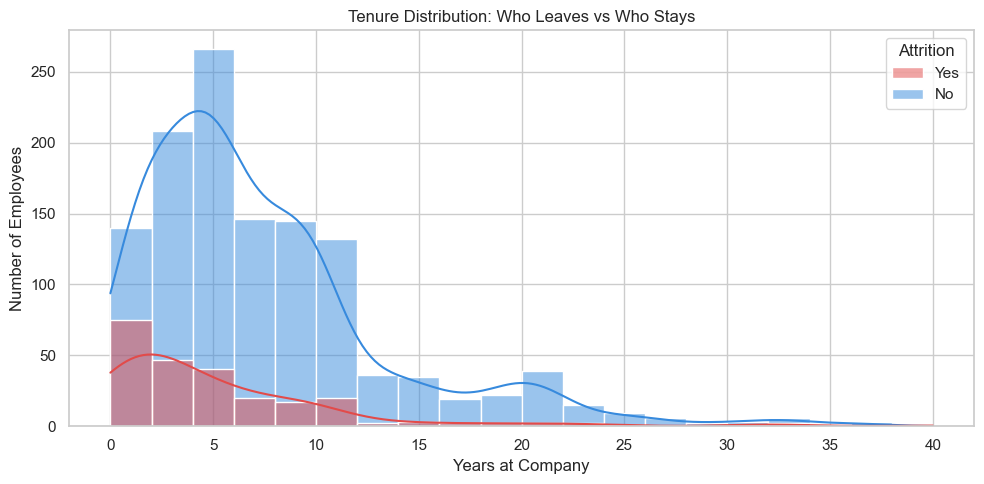

In [7]:
#  STEP 6 — Plot: Tenure (Years at Company) distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    bins=20,
    kde=True,
    palette={"Yes": "#E24B4A", "No": "#378ADD"}
)

plt.title("Tenure Distribution: Who Leaves vs Who Stays")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.savefig("plot2_tenure_distribution.png", dpi=150)
plt.show()

In [8]:
#  STEP 7 — Key Insight: Salary vs Attrition


# ── 7a: Calculate average salary by attrition status ──
salary_by_attrition = df.groupby("Attrition")["MonthlyIncome"].mean().round(0)
print("\nAverage Monthly Income by Attrition:")
print(salary_by_attrition)




Average Monthly Income by Attrition:
Attrition
No     6833.0
Yes    4787.0
Name: MonthlyIncome, dtype: float64


C:\Users\Gandharvi\AppData\Local\Temp\ipykernel_31636\136416214.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


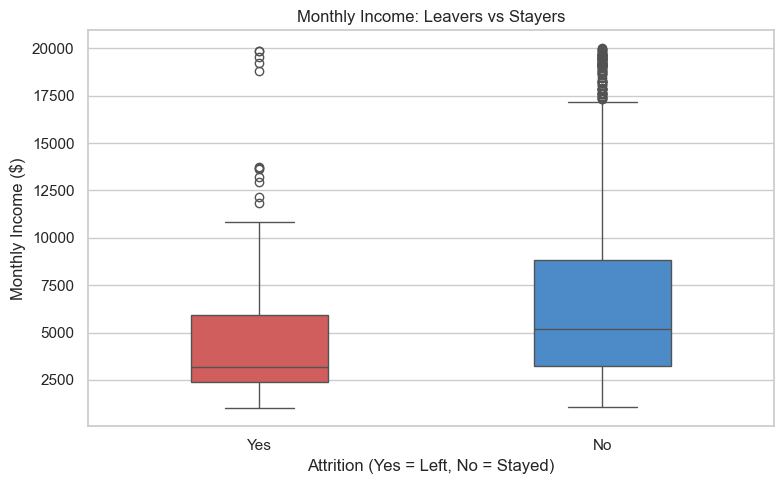

In [9]:
# ── 7b: Box plot — salary distribution for leavers vs stayers ──
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    palette={"Yes": "#E24B4A", "No": "#378ADD"},
    width=0.4
)

plt.title("Monthly Income: Leavers vs Stayers")
plt.xlabel("Attrition (Yes = Left, No = Stayed)")
plt.ylabel("Monthly Income ($)")
plt.tight_layout()
plt.savefig("plot3_salary_vs_attrition.png", dpi=150)
plt.show()

In [10]:
#  STEP 8 — Key Insight: Attrition % per Department

# QUESTION: Which departments have the worst attrition?

# ── 8a: Calculate attrition rate per department ──
dept_attrition = (
    df.groupby("Department")["Attrition_Num"]
    .mean()           # mean of 0s and 1s = percentage who left
    .mul(100)         # convert to percentage
    .round(1)         # round to 1 decimal place
    .reset_index()    # turn the index back into a column
    .rename(columns={"Attrition_Num": "Attrition_Rate_%"})
    .sort_values("Attrition_Rate_%", ascending=False)
)

print("\nAttrition Rate by Department:")
print(dept_attrition)



Attrition Rate by Department:
               Department  Attrition_Rate_%
2                   Sales              20.6
0         Human Resources              19.0
1  Research & Development              13.8


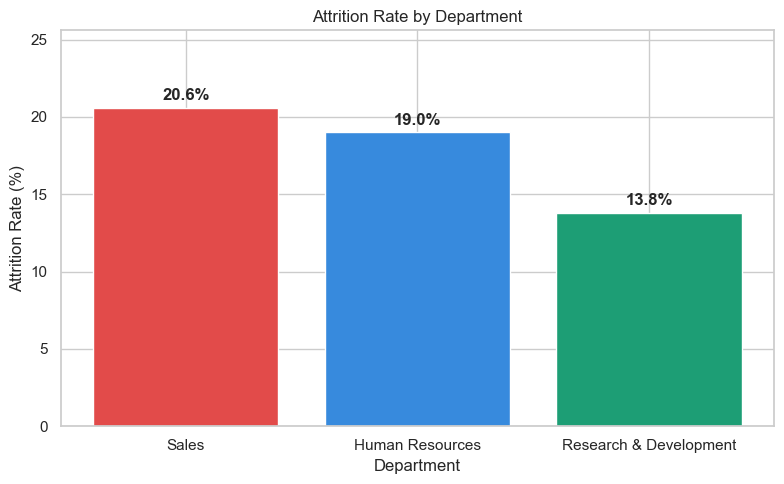

In [11]:
# ── 8b: Bar chart — attrition rate per department ──
plt.figure(figsize=(8, 5))

bars = plt.bar(
    dept_attrition["Department"],
    dept_attrition["Attrition_Rate_%"],
    color=["#E24B4A", "#378ADD", "#1D9E75"]
)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  
        height + 0.3,                         
        f"{height:.1f}%",                      
        ha="center", va="bottom", fontsize=12, fontweight="bold"
    )

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.ylim(0, max(dept_attrition["Attrition_Rate_%"]) + 5)
plt.tight_layout()
plt.savefig("plot4_dept_attrition.png", dpi=150)
plt.show()




Attrition Rate by Overtime:
OverTime
No     10.4
Yes    30.5
Name: Attrition_Num, dtype: float64


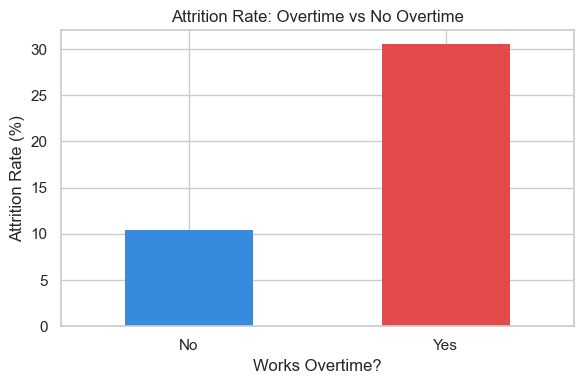

In [12]:
#  STEP 9 — Bonus Insight: Overtime vs Attrition

# QUESTION: Do employees who work overtime leave more?

overtime_attrition = (
    df.groupby("OverTime")["Attrition_Num"]
    .mean()
    .mul(100)
    .round(1)
)
print("\nAttrition Rate by Overtime:")
print(overtime_attrition)

plt.figure(figsize=(6, 4))
overtime_attrition.plot(kind="bar", color=["#378ADD", "#E24B4A"], edgecolor="none")
plt.title("Attrition Rate: Overtime vs No Overtime")
plt.xlabel("Works Overtime?")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot5_overtime_attrition.png", dpi=150)
plt.show()


Top 10 features correlated with Attrition:
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
JobSatisfaction        -0.103481
Name: Attrition_Num, dtype: float64


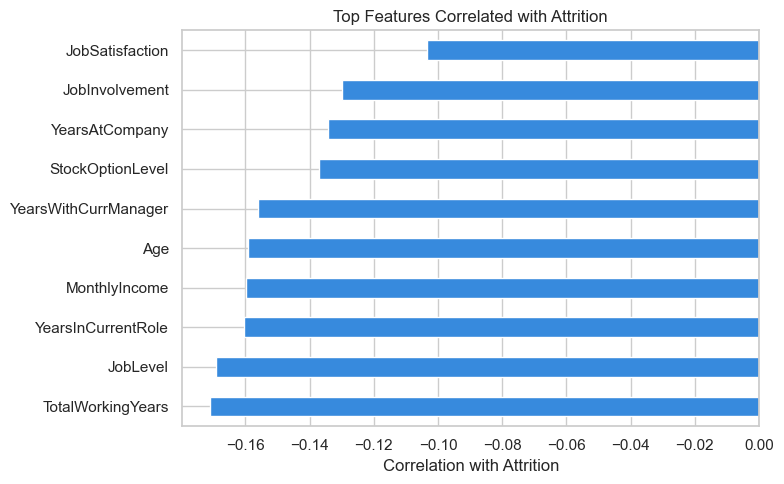

In [19]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include="number")

# Calculate correlation of every column WITH Attrition_Num
# Sort by absolute value so strongest relationships appear first
attrition_corr = (
    numeric_cols.corr()["Attrition_Num"]
    .drop("Attrition_Num")        # remove self-correlation
    .sort_values(key=abs, ascending=False)
    .head(10)                      # top 10 most correlated
)

print("\nTop 10 features correlated with Attrition:")
print(attrition_corr)

# ── Plot the correlations ──
plt.figure(figsize=(8, 5))
colors = ["#E24B4A" if v > 0 else "#378ADD" for v in attrition_corr.values]
attrition_corr.plot(kind="barh", color=colors)
plt.axvline(0, color="gray", linewidth=0.8)
plt.title("Top Features Correlated with Attrition")
plt.xlabel("Correlation with Attrition")
plt.tight_layout()
plt.savefig("plot6_correlation.png", dpi=150)
plt.show()

In [20]:
#  SUMMARY 
print("EDA SUMMARY — KEY FINDINGS")
print("="*50)

total = len(df)
left = df["Attrition_Num"].sum()
attrition_rate = (left / total * 100).round(1)

avg_salary_left = df[df["Attrition"] == "Yes"]["MonthlyIncome"].mean().round(0)
avg_salary_stayed = df[df["Attrition"] == "No"]["MonthlyIncome"].mean().round(0)
salary_diff = (avg_salary_stayed - avg_salary_left).round(0)

print(f"Total employees     : {total}")
print(f"Employees who left  : {int(left)}")
print(f"Overall attrition   : {attrition_rate}%")
print(f"Avg salary (left)   : ${avg_salary_left:,.0f}")
print(f"Avg salary (stayed) : ${avg_salary_stayed:,.0f}")
print(f"Salary gap          : ${salary_diff:,.0f} — leavers earned this much LESS")
print("\nDepartment attrition rates:")
print(dept_attrition.to_string(index=False))
print("\nPlots saved: plot1 through plot6 as PNG files")
print("="*50)

EDA SUMMARY — KEY FINDINGS
Total employees     : 1470
Employees who left  : 237
Overall attrition   : 16.1%
Avg salary (left)   : $4,787
Avg salary (stayed) : $6,833
Salary gap          : $2,046 — leavers earned this much LESS

Department attrition rates:
            Department  Attrition_Rate_%
                 Sales              20.6
       Human Resources              19.0
Research & Development              13.8

Plots saved: plot1 through plot6 as PNG files
